In [13]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
TFIDF_L2 = pd.read_csv("TFIDF_L2.csv", sep="|", index_col=0)
LIB = pd.read_csv("LIB.csv", sep="|", index_col=0)
THETA = pd.read_csv("LDA_THETA.csv", sep="|", index_col="song_id")
TOPICS = pd.read_csv('LDA_TOPICS.csv', sep='|', index_col='topic_id')
DOC_SENT = pd.read_csv('DOC_SENT.csv', sep='|',
    index_col=0)

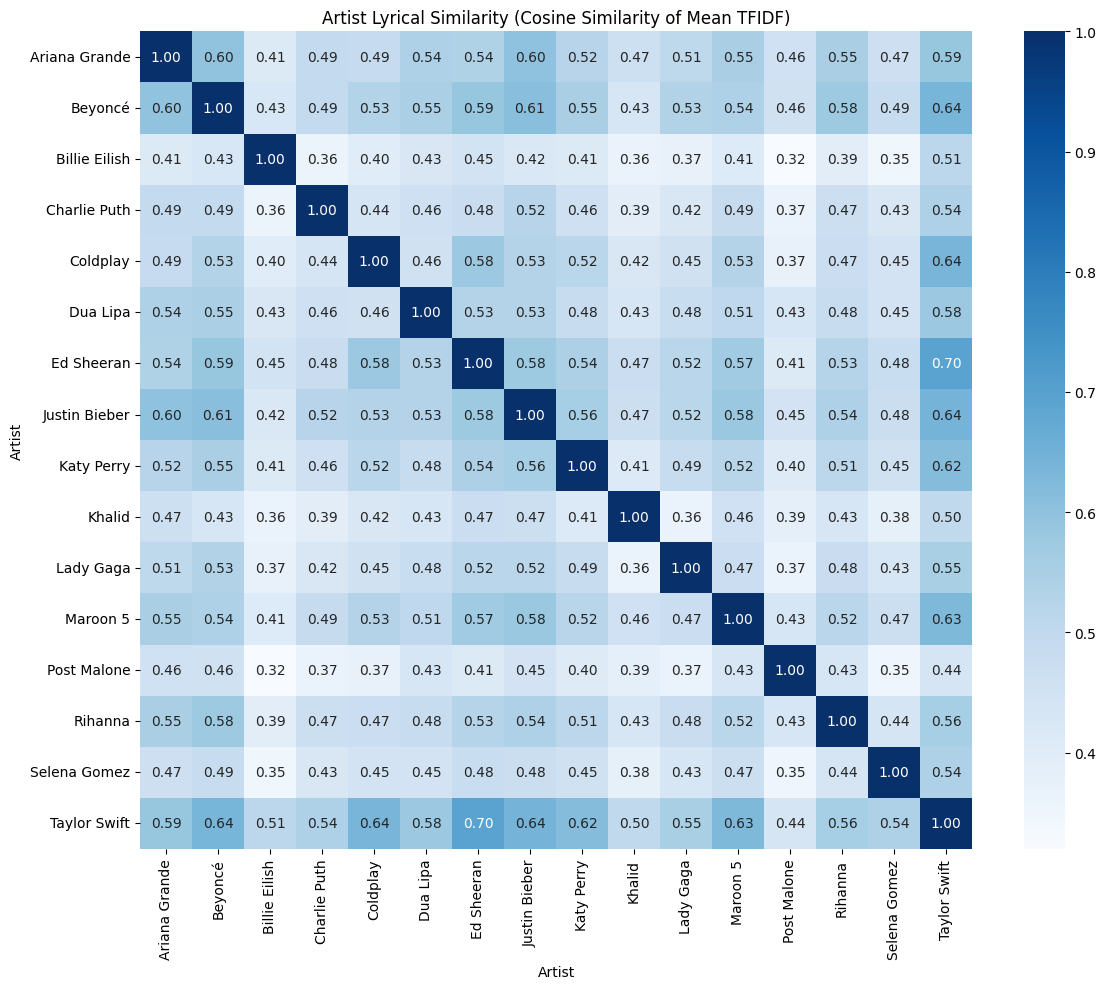

In [24]:
# Mean TFIDF vector per artist
ARTIST_TFIDF = TFIDF_L2.join(LIB[['Artist']]).groupby('Artist').mean()

# Cosine similarity between artists
SIM = pd.DataFrame(
    cosine_similarity(ARTIST_TFIDF),
    index=ARTIST_TFIDF.index,
    columns=ARTIST_TFIDF.index
)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(SIM, cmap='Blues', annot=True, fmt='.2f', ax=ax)
ax.set_title('Artist Lyrical Similarity (Cosine Similarity of Mean TFIDF)')
plt.tight_layout()
plt.show()

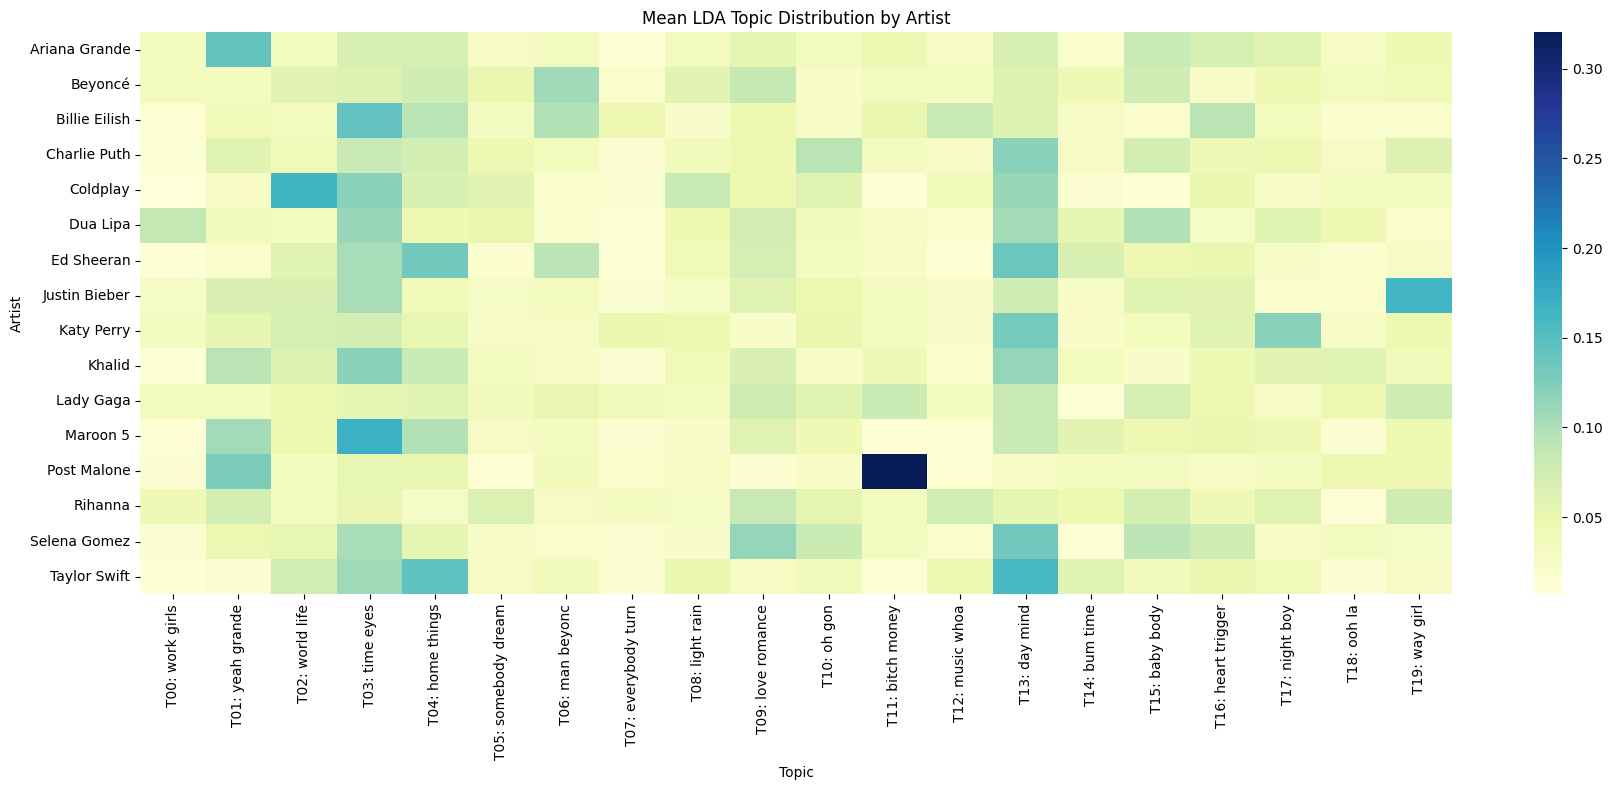

In [19]:
TNAMES = THETA.columns

# Mean topic weight per artist
THETA_LIB = THETA.join(LIB[['Artist']])
ARTIST_TOPICS = THETA_LIB.groupby('Artist')[TNAMES].mean()

# Add top terms as column labels
ARTIST_TOPICS.columns = [
    f"{t}: {' '.join(TOPICS.loc[t, 'top_terms'].split()[:2])}" 
    for t in TNAMES
]

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(ARTIST_TOPICS, cmap='YlGnBu', ax=ax)
ax.set_title('Mean LDA Topic Distribution by Artist')
ax.set_xlabel('Topic')
ax.set_ylabel('Artist')
plt.tight_layout()
plt.show()

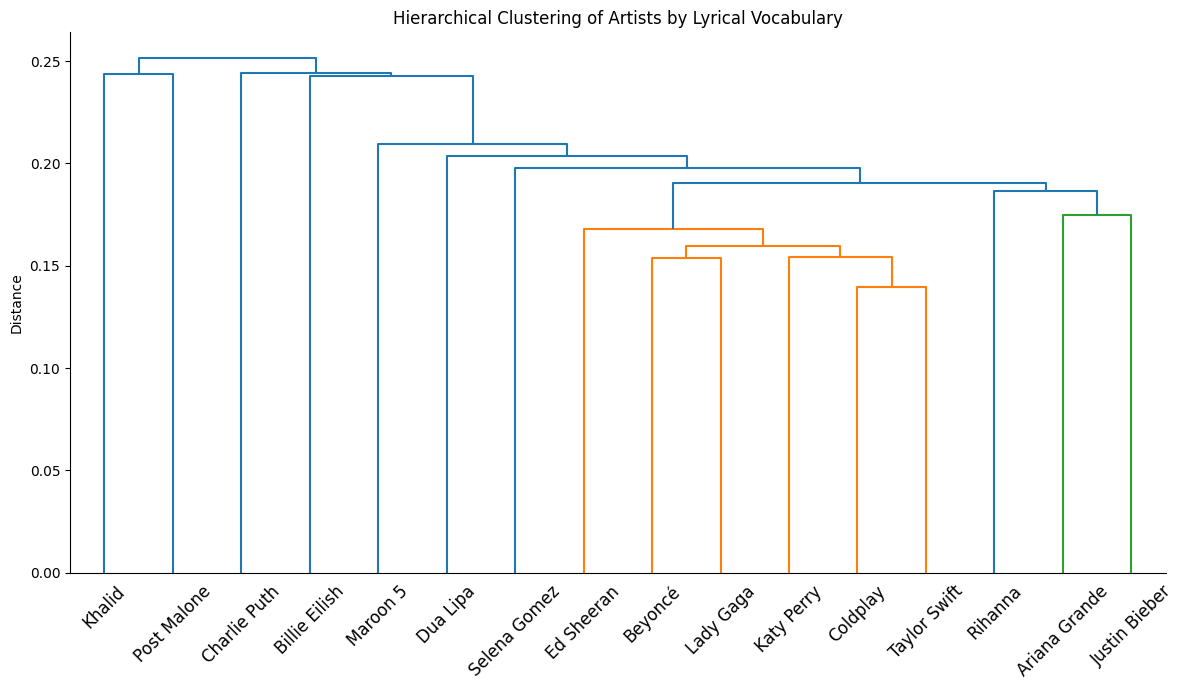

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cosine

# Mean TFIDF vector per artist
ARTIST_TFIDF = TFIDF_L2.join(LIB[['Artist']]).groupby('Artist').mean()

# Hierarchical clustering
linked = linkage(ARTIST_TFIDF, method='ward')

fig, ax = plt.subplots(figsize=(12, 7))
dendrogram(
    linked,
    labels=ARTIST_TFIDF.index.tolist(),
    orientation='top',
    leaf_rotation=45,
    leaf_font_size=12,
    ax=ax
)
ax.set_title('Hierarchical Clustering of Artists by Lyrical Vocabulary')
ax.set_ylabel('Distance')
sns.despine()
plt.tight_layout()
plt.show()

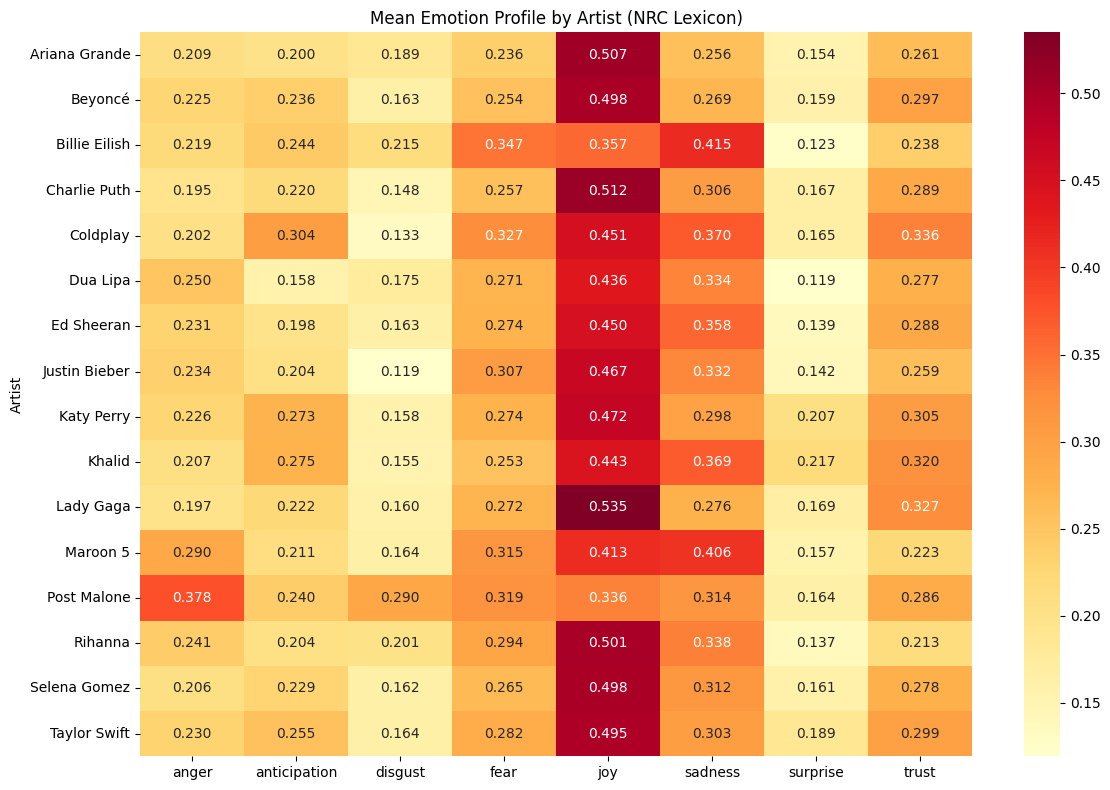

In [28]:
##Riff 1
import seaborn as sns
import matplotlib.pyplot as plt

emo_cols_no_sent = "anger anticipation disgust fear joy sadness surprise trust".split()

ARTIST_EMO = DOC_SENT.groupby('Artist')[emo_cols_no_sent].mean()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(ARTIST_EMO, cmap='YlOrRd', annot=True, fmt='.3f', ax=ax)
ax.set_title('Mean Emotion Profile by Artist (NRC Lexicon)')
plt.tight_layout()
plt.show()

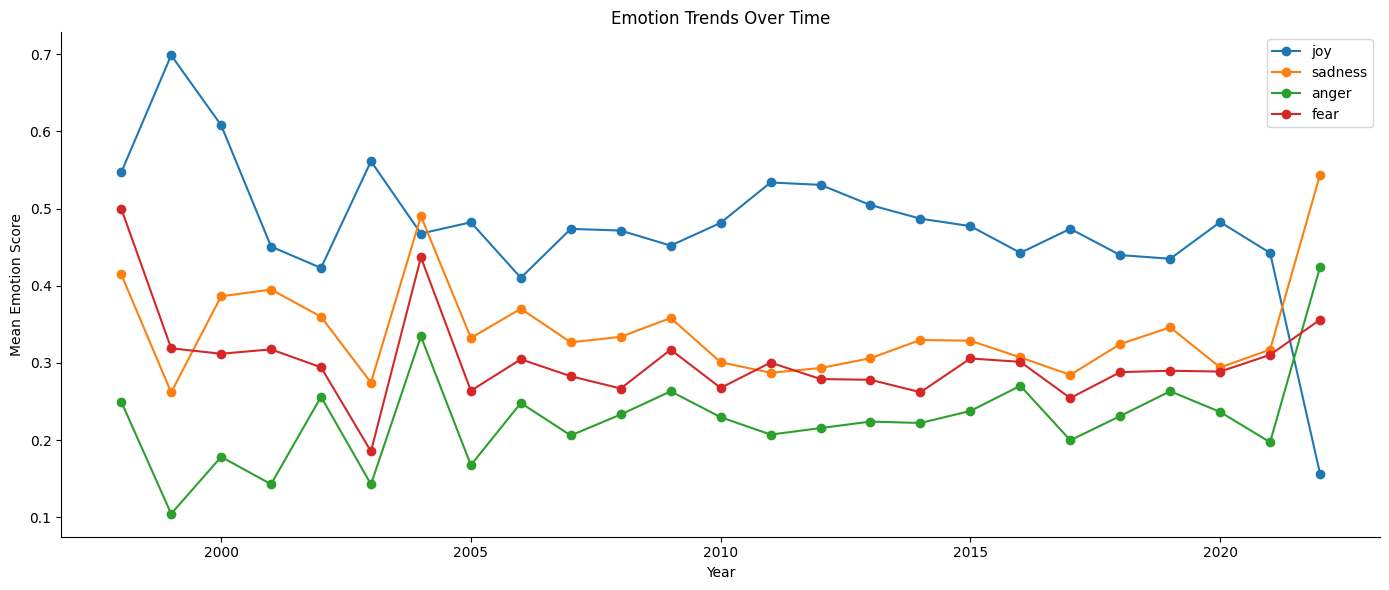

In [29]:
## Another option for Riff 2? 
# Mean sentiment scores per year
YEAR_EMO = DOC_SENT.groupby('Year')[emo_cols_no_sent].mean()
YEAR_EMO = YEAR_EMO[YEAR_EMO.index > 1900]  # filter bad years

fig, ax = plt.subplots(figsize=(14, 6))
YEAR_EMO[['joy', 'sadness', 'anger', 'fear']].plot(ax=ax, marker='o')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Emotion Score')
ax.set_title('Emotion Trends Over Time')
sns.despine()
plt.tight_layout()
plt.show()